In [58]:
# DSC 550
# Week 2
# Fall 2024
# Weeks 2 Exercises
# Created By Matthew Heinen
# 9/2/24

In [59]:
# Import packages. 
import pandas as pd 

#Read in dataset. 
pablo_sweeper = pd.read_csv("Pablo_Home_Sweeper.csv")


In [60]:
pablo_sweeper.head(10)

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,ST,2024-08-30,85.5,-1.35,5.51,"López, Pablo",677870,641154,NaN,ball,...,2,0,2,Standard,Standard,38,0.000,0.030,NaN,NaN
1,ST,2024-08-30,84.8,-1.69,5.44,"López, Pablo",677870,641154,NaN,called_strike,...,2,0,2,Standard,Standard,50,0.000,-0.041,NaN,NaN
2,ST,2024-08-30,84.7,-1.40,5.38,"López, Pablo",676391,641154,NaN,foul,...,2,0,2,Standard,Standard,50,0.000,0.000,55.66155,7.48325
3,ST,2024-08-30,83.6,-1.37,5.55,"López, Pablo",665489,641154,NaN,ball,...,2,0,2,Standard,Standard,48,0.000,0.033,NaN,NaN
4,ST,2024-08-30,84.9,-1.78,5.35,"López, Pablo",662139,641154,field_out,hit_into_play,...,2,0,2,Standard,Standard,47,0.048,-0.359,65.95864,8.43728
5,ST,2024-08-30,85.5,-1.47,5.43,"López, Pablo",672386,641154,NaN,ball,...,0,0,0,Standard,Standard,38,0.000,0.075,NaN,NaN
6,ST,2024-08-30,85.2,-1.72,5.49,"López, Pablo",662139,641154,NaN,ball,...,0,0,0,Standard,Standard,46,0.000,0.033,NaN,NaN
7,ST,2024-08-30,83.3,-1.53,5.47,"López, Pablo",677870,641154,field_out,hit_into_play,...,0,0,0,Standard,Standard,49,0.011,-0.062,64.25537,8.05624
8,ST,2024-08-30,85.6,-1.70,5.45,"López, Pablo",677870,641154,NaN,called_strike,...,0,0,0,Standard,Standard,55,0.000,-0.015,NaN,NaN
9,ST,2024-08-30,85.0,-1.52,5.56,"López, Pablo",676391,641154,field_out,hit_into_play,...,0,0,0,Standard,Standard,47,0.025,-0.148,65.15164,6.59653


In [61]:
# Select the columns we wish to use for analysis. 
#Include: stand (batter handedness), release_speed, pfx_x, pfx_z, plate_x, Plate_z, 
# release_spin_rate, spin_axis,  delta_home_win_exp, delta_run_exp

# Make a list of selected columns

selected_columns = [
    'game_date',
    'stand', 
    'release_speed', 
    'pfx_x', 
    'pfx_z', 
    'plate_x', 
    'plate_z', 
    'release_spin_rate', 
    'spin_axis', 
    'delta_home_win_exp', 
    'delta_run_exp'
]


In [62]:
# Filter down our dataframe to only include metrics we will use for analysis. 
pablo_sweeper = pablo_sweeper[selected_columns]

In [63]:
# display df
pablo_sweeper.head(10)

,game_date,stand,release_speed,pfx_x,pfx_z,plate_x,plate_z,release_spin_rate,spin_axis,delta_home_win_exp,delta_run_exp
0,2024-08-30,R,85.5,1.24,-0.19,3.38,1.21,2572,38,0.000,0.030
1,2024-08-30,R,84.8,1.19,-0.16,-0.17,1.50,2523,50,0.000,-0.041
2,2024-08-30,R,84.7,0.87,-0.08,1.48,1.43,2409,50,0.000,0.000
3,2024-08-30,R,83.6,1.16,-0.41,1.39,1.71,2576,48,0.000,0.033
4,2024-08-30,L,84.9,0.98,0.03,-0.17,2.04,2415,47,0.048,-0.359
5,2024-08-30,R,85.5,1.03,-0.09,1.99,0.91,2465,38,0.000,0.075
6,2024-08-30,L,85.2,1.13,0.01,1.05,1.83,2458,46,0.000,0.033
7,2024-08-30,R,83.3,1.11,-0.30,1.12,1.59,2398,49,0.011,-0.062
8,2024-08-30,R,85.6,1.03,0.23,0.34,2.38,2470,55,0.000,-0.015
9,2024-08-30,R,85.0,1.13,-0.11,0.52,2.80,2442,47,0.025,-0.148


In [64]:
# Display df shape
pablo_sweeper.shape


(583, 11)

## 1) Using a data set of your choice, write an introduction explaining the data set.

        The data set we have selected is a collection of metrics from the last 2 years of MLB pitcher Pablo Lopez's careers. The dataset contains information on every sweeper that he has thrown at home. It includes the following variables: 

game date,
stand (batter handedness), 
release speed,
pfx_x( horizontal pitch break),
pfx_z(vertical pitch break), 
plate_x (pitch location as the ball crosses home plate horizontally), 
plate_z (pitch location as the ball crosses home plate vertically),
release spin rate,
spin axis (The Spin Axis in the 2D X-Z plane in degrees from 0 to 360, such that 180 represents a pure backspin fastball and 0 degrees represents a pure topspin (12-6) curveball),
delta_home_win_exp( change in home win expectancy %),
delta_run_exp (change in run expectancy, in the context of this project negative run expectancy is a good result for the pitcher pablo lopez.)

This data set contains information that will allow us to evaluate the effectiveness of lopez's sweeper and what makes it effective. 


## 2) Identify a question or question(s) that you would like to explore in your data set.

        Pablo Lopez added the sweeper to his arsenal in 2023 and the general sentiment of the public was that is was a very successful pitch for him and a great add to his arsenal. fast forward to 2024 and the sentiment has changed. Public perception is that Pablo's sweeper has become far less effective. In this exercise i would like to evaluate the truth in the change of general sentiment around Pablo's sweeper. Additionally I would like to see what makes Pablo's sweeper successful or unsuccessful. Potentially this information could help inform a player and allow them to maximize pitch effectiveness. 

## 3) Create at least three graphs that help answer these questions. Make sure your graphs are clearly readable and are labeled appropriately and professionally.

### a) Evaluate Palblo's sweeper effectiveness by year and graph. 

In [69]:
# First we need to create a date column in the dataset to evaluate annually. 

# Convert the 'game_date' column to datetime format
pablo_sweeper['game_date'] = pd.to_datetime(pablo_sweeper['game_date'])

# Extract the year from the 'game_date' column
pablo_sweeper['year'] = pablo_sweeper['game_date'].dt.year

In [70]:
# build new df finding average change in run expectancy. 
# group by year. 
avg_run_exp = pablo_sweeper.groupby('year')['delta_run_exp'].mean().reset_index()


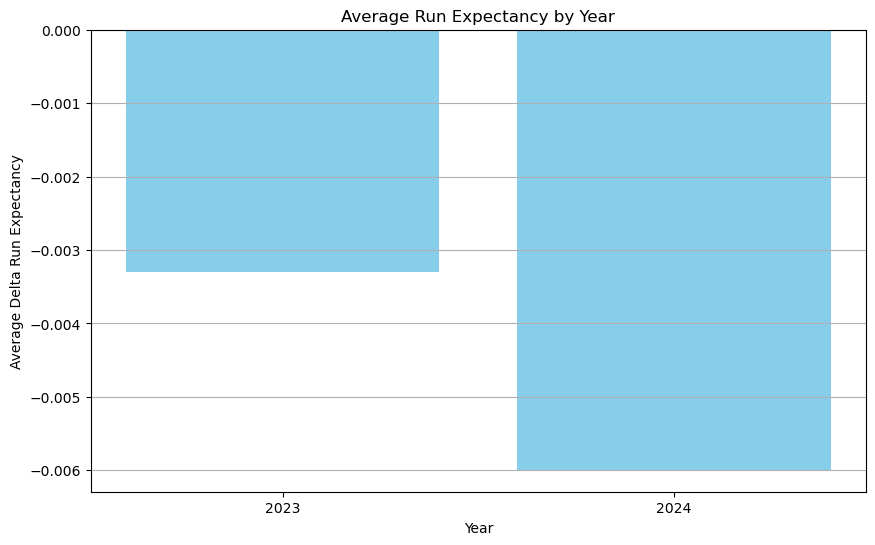

In [72]:
# Build Bar graph showing results. 

# Import packages
import matplotlib.pyplot as plt

# Build bar graph. 
# Set figure size
plt.figure(figsize=(10, 6))
# bar chart
plt.bar(avg_run_exp['year'], avg_run_exp['delta_run_exp'], color='skyblue')

# Labels
plt.title('Average Run Expectancy by Year')
plt.xlabel('Year')
plt.ylabel('Average Change in Run Expectancy')

# Axis formatting
# Format x tics as integers to remove excess labels. 
plt.xticks(avg_run_exp['year'].astype(int))
# Add grid lines to improve readability. 
plt.grid(axis='y')  
plt.show()

In [74]:
# Lets repeat the above steps and evaluate the change in home win expectancy percentage by year. 

# build new df finding average change home win expectancy. 
# group by year. 
avg_home_win_exp = pablo_sweeper.groupby('year')['delta_home_win_exp'].mean().reset_index()


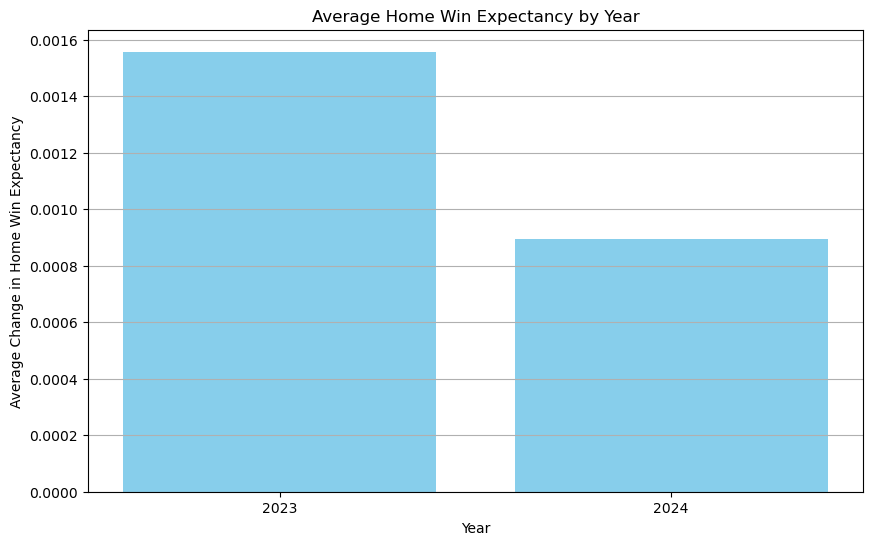

In [76]:
# Build Bar graph showing results. 

# Import packages
import matplotlib.pyplot as plt

# Build bar graph. 
# Set figure size
plt.figure(figsize=(10, 6))
# bar chart
plt.bar(avg_home_win_exp['year'], avg_home_win_exp['delta_home_win_exp'], color='skyblue')

# Labels
plt.title('Average Home Win Expectancy by Year')
plt.xlabel('Year')
plt.ylabel('Average Change in Home Win Expectancy')

# Axis formatting
# Format x tics as integers to remove excess labels. 
plt.xticks(avg_home_win_exp['year'].astype(int))
# Add grid lines to improve readability. 
plt.grid(axis='y')  
plt.show()

        As we look at the graphs above we see a differing trend from the change in run expectancy and the change in home win expectancy by year. When looking at 2024 change in run expectancy by by year we see that the Sweeper actually contributes to a greater decrease in run expectancy in 2024 than 2023. This phenomena actually contradicts the common sentiment that Pablo's sweeper has become less effective this season. However, When we evaluate the results of the second bar chart displaying the change in home win expectancy. The sweeper has actually contributed to less of a positive change in home win expectancy than in 2023, however, the sweeper is still contributing to a positive change meaning that it is an effective pitch for Pablo Lopez. 

### b) Evaluate Sweeper effectiveness by spin rate, direction and veloity. 

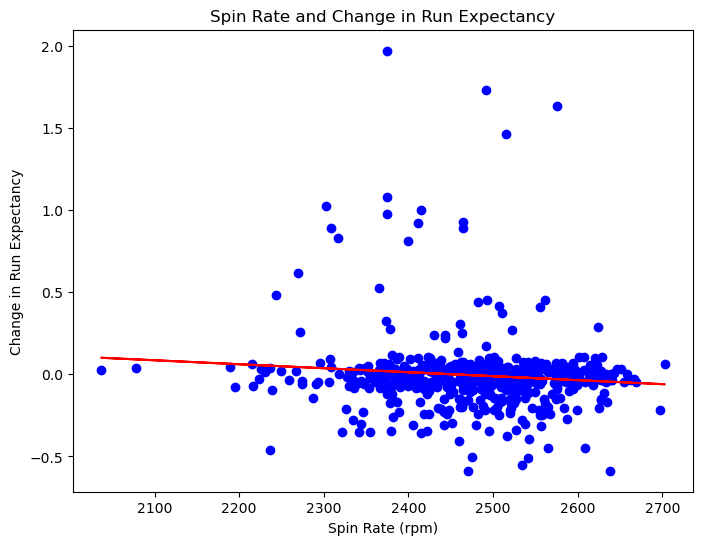

In [89]:
# Import necessary packages. 
import numpy as np
import matplotlib.pyplot as plt


# Build scatter plot to evaluate the effectiveness of spin rate. 
# Size 
plt.figure(figsize=(8, 6))
# Build scatter plot
plt.scatter(pablo_sweeper['release_spin_rate'], pablo_sweeper['delta_run_exp'], color='b', marker='o')

# Use numpy to add a trendline
# Define coefficients
coefficients = np.polyfit(pablo_sweeper['release_spin_rate'], pablo_sweeper['delta_run_exp'], 1)
# Define Trendline
trendline = np.poly1d(coefficients)
# plot Trendline
plt.plot(pablo_sweeper['release_spin_rate'], trendline(pablo_sweeper['release_spin_rate']), color='r', label='Trendline')
# Add labels and title
plt.title('Spin Rate and Change in Run Expectancy')
plt.xlabel('Spin Rate (rpm)')
plt.ylabel('Change in Run Expectancy')

# Display the plot
plt.show()

In [101]:
# Lets now define this trend line and as a linear regression model to evaluate the effects of Spin Rate on Change in Run expectancy. 

# Import packages
import statsmodels.formula.api as smf

# build model
model = smf.ols('delta_run_exp ~ release_spin_rate', data=pablo_sweeper)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          delta_run_exp   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.870
Date:                Thu, 05 Sep 2024   Prob (F-statistic):             0.0157
Time:                        11:54:15   Log-Likelihood:                 26.818
No. Observations:                 583   AIC:                            -49.64
Df Residuals:                     581   BIC:                            -40.90
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.5954      0.248      2.403      0.017       0.109       1.082
release_spin_rate    -0.0002      0.000     -2.423      0.016      -0.000   -4.59e-05
==============================================================================
Omnibus:                      512.941   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15504.808
Skew:                           3.799   Prob(JB):                         0.00
Kurtosis:                      27.094   Cond. No.                     6.40e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.4e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

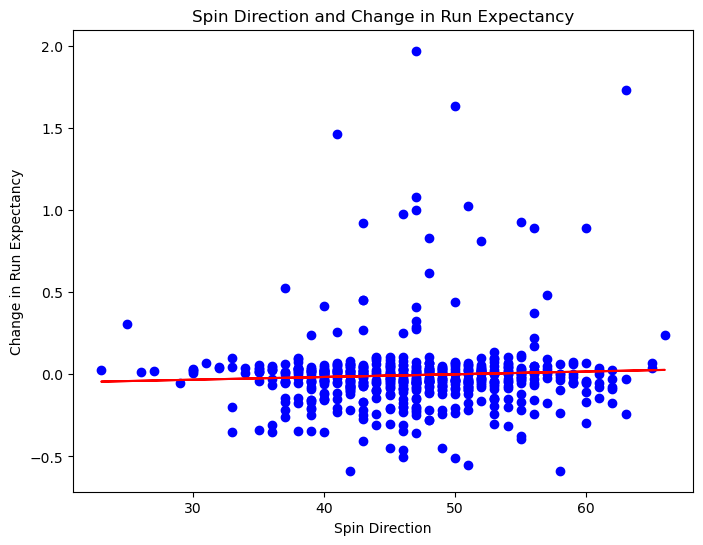

In [97]:
# Build scatter plot to evaluate the effectiveness of spin direction. 
# Size 
plt.figure(figsize=(8, 6))
# Build scatter plot
plt.scatter(pablo_sweeper['spin_axis'], pablo_sweeper['delta_run_exp'], color='b', marker='o')

# Use numpy to add a trendline
# Define coefficients
coefficients = np.polyfit(pablo_sweeper['spin_axis'], pablo_sweeper['delta_run_exp'], 1)
# Define Trendline
trendline = np.poly1d(coefficients)
# plot Trendline
plt.plot(pablo_sweeper['spin_axis'], trendline(pablo_sweeper['spin_axis']), color='r', label='Trendline')
# Add labels and title
plt.title('Spin Direction and Change in Run Expectancy')
plt.xlabel('Spin Direction')
plt.ylabel('Change in Run Expectancy')

# Display the plot
plt.show()

In [105]:
# Lets now define this trend line and as a linear regression model to evaluate the effects of Spin Direction on Change in Run expectancy. 

# Import packages
import statsmodels.formula.api as smf

# build model
model = smf.ols('delta_run_exp ~ spin_axis', data=pablo_sweeper)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          delta_run_exp   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.505
Date:                Thu, 05 Sep 2024   Prob (F-statistic):              0.220
Time:                        11:55:36   Log-Likelihood:                 24.641
No. Observations:                 583   AIC:                            -45.28
Df Residuals:                     581   BIC:                            -36.55
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0822      0.064     -1.284      0.200      -0.208       0.044
spin_axis      0.0017      0.001      1.227      0.220      -0.001       0.004
==============================================================================
Omnibus:                      511.324   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15142.743
Skew:                           3.789   Prob(JB):                         0.00
Kurtosis:                      26.789   Cond. No.                         315.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

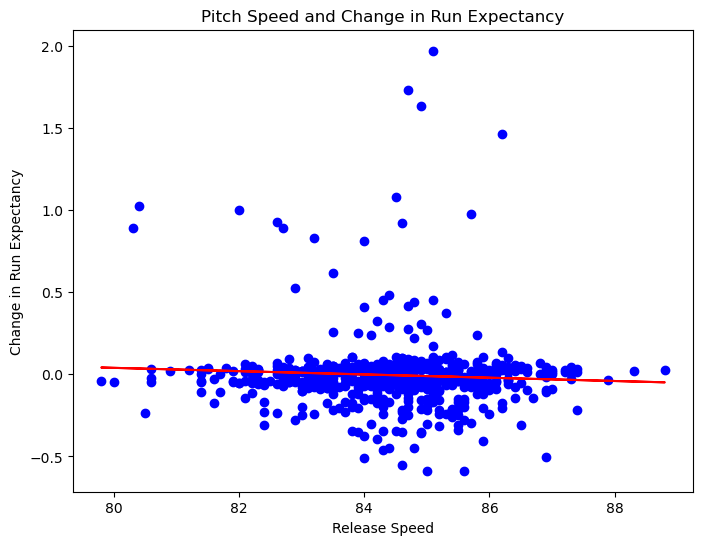

In [99]:
# Build scatter plot to evaluate the effectiveness of pitch speed. 
# Size 
plt.figure(figsize=(8, 6))
# Build scatter plot
plt.scatter(pablo_sweeper['release_speed'], pablo_sweeper['delta_run_exp'], color='b', marker='o')

# Use numpy to add a trendline
# Define coefficients
coefficients = np.polyfit(pablo_sweeper['release_speed'], pablo_sweeper['delta_run_exp'], 1)
# Define Trendline
trendline = np.poly1d(coefficients)
# plot Trendline
plt.plot(pablo_sweeper['release_speed'], trendline(pablo_sweeper['release_speed']), color='r', label='Trendline')
# Add labels and title
plt.title('Pitch Speed and Change in Run Expectancy')
plt.xlabel('Release Speed')
plt.ylabel('Change in Run Expectancy')

# Display the plot
plt.show()

In [107]:
# Lets now define this trend line and as a linear regression model to evaluate the effects of pitch speed on Change in Run expectancy. 

# Import packages
import statsmodels.formula.api as smf

# build model
model = smf.ols('delta_run_exp ~ release_speed', data=pablo_sweeper)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          delta_run_exp   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.061
Date:                Thu, 05 Sep 2024   Prob (F-statistic):              0.152
Time:                        11:56:14   Log-Likelihood:                 24.919
No. Observations:                 583   AIC:                            -45.84
Df Residuals:                     581   BIC:                            -37.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8415      0.589      1.428      0.154      -0.316       1.999
release_speed    -0.0100      0.007     -1.436      0.152      -0.024       0.004
==============================================================================
Omnibus:                      516.366   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15772.124
Skew:                           3.836   Prob(JB):                         0.00
Kurtosis:                      27.299   Cond. No.                     5.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

        Evaluating the 3 scattar plots above we can conclude that Pablo's Sweeper is generally more effective at decreasing run expectancy when it is thrown with a higher spin rate, More topspin and thrown faster. Now as we evaluate these trendlines we see that only one predictor is statistically significant, release spin. This metric however only explains one percent of the variance in the data. Therefore we can conclude that these metrics are only one part of the equation that makes Pablo's sweeper effective at decreasing run expectancy. 

### c) evaluate the pitch locations effect on change in run expectancy. 


    In order to evaluate pitch location effectively lets evaluate for both left and righthanded batters. 

In [120]:
# Filter dataset for pitches thrown to righties. 

sweeper_r = pablo_sweeper[pablo_sweeper['stand'] == 'R']

# Filter dataset for pitches thrown to lefties
sweeper_l = pablo_sweeper[pablo_sweeper['stand'] == 'L']

/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


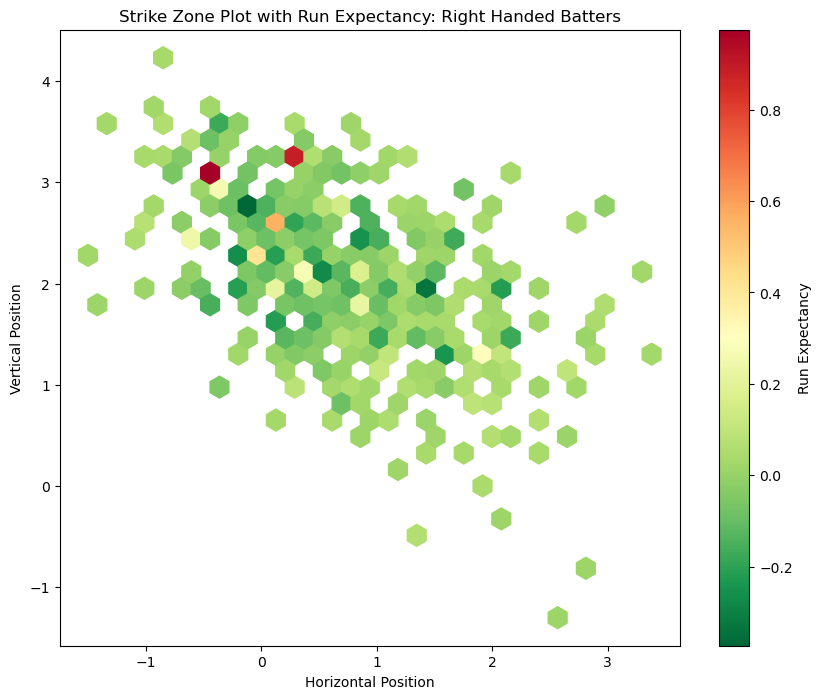

In [130]:
# Build a hexbin plot to show the effect of pitch location on change in run expectancy. 
# Use Right handed batters. 

# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt


# Create the hexbin plot
plt.figure(figsize=(10, 8))
# use reduce_C_function=np.mean to find the mean run expectancy for hexagon 
# inverse the RdYlRn color scale to make negative values green. 
hb = plt.hexbin(sweeper_r['plate_x'], sweeper_r['plate_z'], C=sweeper_r['delta_run_exp'], gridsize=30, cmap='RdYlGn_r', reduce_C_function=np.mean)

# Add a color key to show run expectancy value
cb = plt.colorbar(hb, label='Run Expectancy')

# Add labels and title
plt.xlabel('Horizontal Position')
plt.ylabel('Vertical Position')
plt.title('Strike Zone Plot with Run Expectancy: Right Handed Batters')

# Display the plot
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


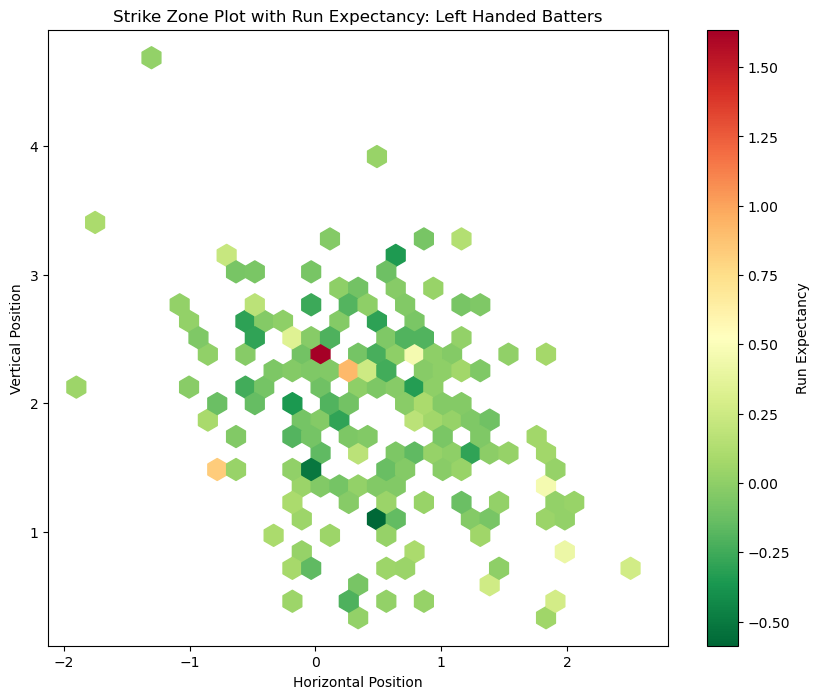

In [134]:
# Build a hexbin plot to show the effect of pitch location on change in run expectancy. 
# Use left handed batters. 

# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt


# Create the hexbin plot
plt.figure(figsize=(10, 8))
# use reduce_C_function=np.mean to find the mean run expectancy for hexagon 
# inverse the RdYlRn color scale to make negative values green. 
hb = plt.hexbin(sweeper_l['plate_x'], sweeper_l['plate_z'], C=sweeper_l['delta_run_exp'], gridsize=30, cmap='RdYlGn_r', reduce_C_function=np.mean)

# Add a color key to show run expectancy value
cb = plt.colorbar(hb, label='Run Expectancy')

# Add labels and title
plt.xlabel('Horizontal Position')
plt.ylabel('Vertical Position')
plt.title('Strike Zone Plot with Run Expectancy: Left Handed Batters')

# Display the plot
plt.show()

        When evaluating the effectiveness of Pablo's Sweeper while being thrown to right-handers we can see the pitch is very effective as long as it is not high and inside in this segment we that the sweeper is actually contributing to positive change in run expectancy making the pitch ineffective. To lefties as long s the pitch is not in the middle of the strikezone the pitch seems to be relatively effective. The pitch is most effective contributing to the largest decrease in run expectancy low in the zone to left handed hitters. 

## 5) Write a conclusion that summarizes your findings.

        All together we found that although the general sentiment aboung fans may be that Lopez's slider was less effective in 2024 than it was in 2023 there is no data to support that theory. In fact, the sweeper on average actuallly created a greater decrease in run expectancy in 2024 making it a more effective pitch for run supression. Additionally we found that the sweeper is most effective for Pablo when thrown fast with a high rate of topspin. Finally our hexbin plot shows that the sweeper is an effective pitch at reducing run expectency in most cases as long as it is not thrown up and in to righties and middle middle to lefties, in these two circumstances the sweeper actually lead to positive run expectency making the pitich inneffective. 